# 🛠️ Notebook 02: Feature Engineering

**Goal**: Create predictive features from OHLCV data without introducing data leakage.

**Key Features Created**:
1. Lag Features (Past values)
2. Moving Averages (Trend)
3. RSI (Momentum)
4. Bollinger Bands (Volatility)

---

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

from src.data.loader import NVDADataLoader
from src.features.engineering import FeatureEngineer

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

## 1. Load Data

In [2]:
DATA_PATH = '../data/raw/NVDA_yfinance_clean.csv'
loader = NVDADataLoader(DATA_PATH)
df, report = loader.load_and_validate(verbose=True)
print(f"Data loaded: {df.shape}")
df.head()

✅ Loaded 2,514 rows from NVDA_yfinance_clean.csv

                             📊 DATA QUALITY REPORT                              

📏 Dimensions: 2,514 rows × 6 columns
📅 Date Range: 2016-01-04 to 2025-12-31
🔢 Duplicate Rows: 0
❓ Total Missing Values: 0

--------------------------------------------------------------------------------
✅ VALIDATION PASSED - Data quality is excellent!

Data loaded: (2514, 6)


,Date,Close,High,Low,Open,Volume
0,2016-01-04,0.789588,0.794710,0.781538,0.787636,358076000
1,2016-01-05,0.802272,0.815688,0.792759,0.804467,490272000
2,2016-01-06,0.769098,0.792759,0.760073,0.789100,449344000
3,2016-01-07,0.738607,0.754950,0.728850,0.749828,645304000
4,2016-01-08,0.722752,0.748852,0.721289,0.748120,398472000


## 2. Apply Feature Engineering
We use the `FeatureEngineer` class from `src.features` to ensure consistency between training and production.

In [3]:
engineer = FeatureEngineer()
df_features = engineer.create_features(df)

# Drop NaN values created by lags/rolling windows for visualization
df_clean = df_features.dropna()
print(f"Data with features: {df_clean.shape}")
df_clean.tail()

Data with features: (2315, 26)


,Date,Close,High,Low,Open,Volume,Daily_Return,Prev_Day_Return,MA_7,MA_50,...,Close_Lag_1,Volume_Lag_1,Close_Lag_2,Volume_Lag_2,Close_Lag_3,Volume_Lag_3,Close_Lag_5,Volume_Lag_5,Close_Lag_7,Volume_Lag_7
2509,2025-12-24,188.610001,188.910004,186.589996,187.940002,65528500,-0.003171,0.030051,180.757145,185.844280,...,189.210007,174873600.0,183.690002,129064400.0,180.990005,324925900.0,170.940002,222775500.0,176.289993,164775600.0
2510,2025-12-26,190.529999,192.690002,188.000000,189.919998,139740300,0.010180,-0.003171,182.587145,186.058481,...,188.610001,65528500.0,189.210007,174873600.0,183.690002,129064400.0,174.139999,176096000.0,177.720001,148588100.0
2511,2025-12-29,188.220001,188.759995,185.910004,187.710007,120006100,-0.012124,0.010180,185.055716,186.186883,...,190.529999,139740300.0,188.610001,65528500.0,189.210007,174873600.0,180.990005,324925900.0,170.940002,222775500.0
2512,2025-12-30,187.539993,188.990005,186.929993,188.240005,97687300,-0.003613,-0.012124,186.970001,186.273487,...,188.220001,120006100.0,190.529999,139740300.0,188.610001,65528500.0,183.690002,129064400.0,174.139999,176096000.0
2513,2025-12-31,186.500000,190.559998,186.490005,189.570007,120100500,-0.005545,-0.003613,187.757143,186.350890,...,187.539993,97687300.0,188.220001,120006100.0,190.529999,139740300.0,189.210007,174873600.0,180.990005,324925900.0


## 3. Visualize Features
### Bollinger Bands

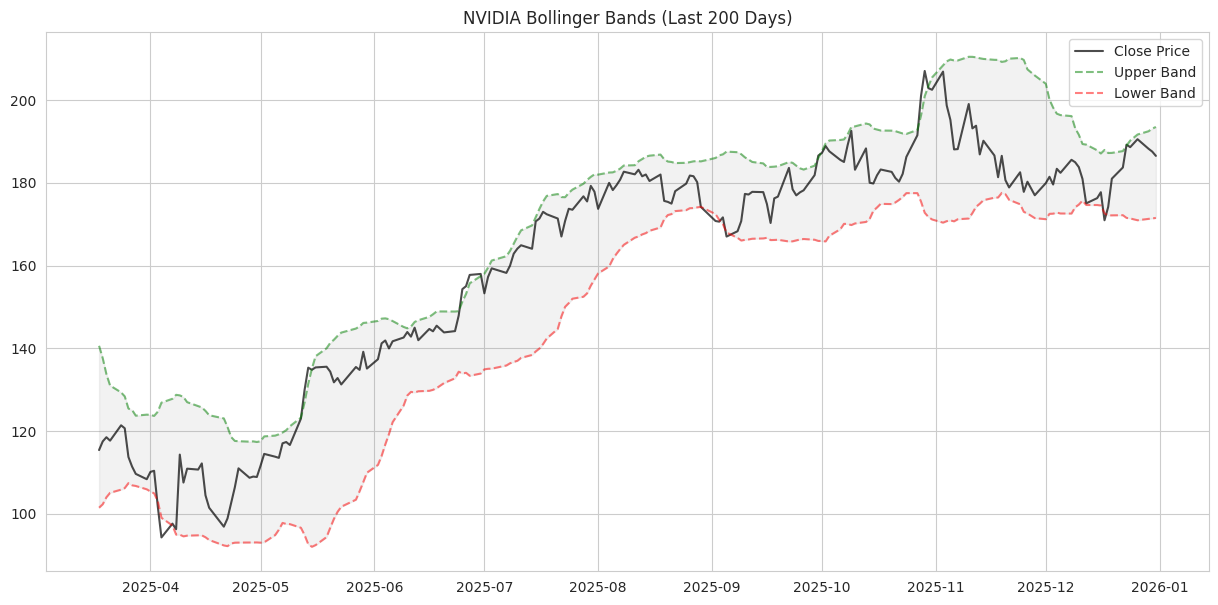

In [4]:
subset = df_clean.iloc[-200:] # Last 200 days

plt.figure(figsize=(15, 7))
plt.plot(subset['Date'], subset['Close'], label='Close Price', color='black', alpha=0.7)
plt.plot(subset['Date'], subset['BB_Upper'], label='Upper Band', color='green', linestyle='--', alpha=0.5)
plt.plot(subset['Date'], subset['BB_Lower'], label='Lower Band', color='red', linestyle='--', alpha=0.5)
plt.fill_between(subset['Date'], subset['BB_Lower'], subset['BB_Upper'], color='gray', alpha=0.1)
plt.title('NVIDIA Bollinger Bands (Last 200 Days)')
plt.legend()
plt.show()

### RSI (Relative Strength Index)

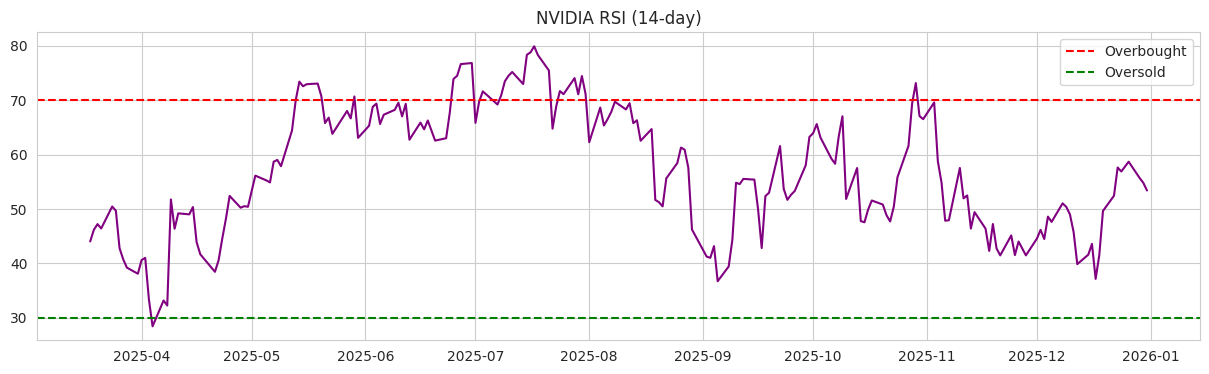

In [5]:
plt.figure(figsize=(15, 4))
plt.plot(subset['Date'], subset['RSI'], color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title('NVIDIA RSI (14-day)')
plt.legend()
plt.show()

## 4. Leakage Validation
We must ensure that features at time `t` do not use information from `t+1`.

**Check**: Does `Close_Lag_1` at index `i` equal `Close` at index `i-1`?

In [6]:
# Verification
sample_idx = 100
current_row = df_features.iloc[sample_idx]
prev_row = df_features.iloc[sample_idx - 1]

print(f"Date T: {current_row['Date']}")
print(f"Date T-1: {prev_row['Date']}")
print(f"Close at T-1: {prev_row['Close']}")
print(f"Close_Lag_1 at T: {current_row['Close_Lag_1']}")

assert current_row['Close_Lag_1'] == prev_row['Close'], "❌ LEAKAGE DETECTED: Lag 1 does not match previous close!"
print("✅ Lag feature validation passed.")

Date T: 2016-05-26 00:00:00
Date T-1: 2016-05-25 00:00:00
Close at T-1: 1.1086983680725098
Close_Lag_1 at T: 1.1086983680725098
✅ Lag feature validation passed.
